# Metrics for regression

### MAE, MSE, RMSE, R squared, MAPE and the pinball loss, and what each one is willing to sacrifice

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why minimising MAE gives you the median and minimising MSE gives you the mean, and why that makes them prefer different models on skewed data; how a handful of large errors takes over RMSE and barely touches MAE; what "explains 60% of the variance" actually says, why R squared travels between datasets when RMSE does not, and how it goes negative; the two ways MAPE breaks; and how to pick a metric from the cost of being wrong |
| **You should already know** | [Metrics for classification](../05-classification-metrics/), [cross-validation](../04-cross-validation/) |
| **Datasets** | California Housing, UCI Bike Sharing |
| **Runtime** | Under a minute on a laptop CPU |
| **Next** | [01-07 Feature scaling and encoding](../07-feature-scaling-and-encoding/) |

---

## 1. Every metric optimises something different

In classification a metric and a loss are usually separate objects: you train
against cross-entropy and then report accuracy, precision, recall. In regression
they are the same arithmetic seen twice. The thing you minimise while fitting and
the thing you print at the end are typically the same formula, and when they are
not, you have quietly asked for one model and graded it as another.

So the question "which regression metric should I use" is really the question
"which model do I want". A metric is a statement about what counts as being
wrong, and different statements pick out genuinely different models from the same
data. This notebook is mostly about proving that rather than asserting it.

Two datasets, chosen because they break in different places.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

In [2]:
X_cal, y_cal = datasets.california_housing()
X_bike, y_bike = datasets.bike_sharing()

cal = y_cal.to_numpy(dtype=float)
bike = y_bike.to_numpy(dtype=float)

summary = pd.DataFrame({
    "California (100k$)": [len(cal), cal.min(), cal.mean(), np.median(cal), cal.max(),
                           y_cal.skew()],
    "Bike hires (per hour)": [len(bike), bike.min(), bike.mean(), np.median(bike), bike.max(),
                              y_bike.skew()],
}, index=["rows", "min", "mean", "median", "max", "skew"])
print(summary.round(3).to_string())

capped = cal >= 4.999
print(f"\nCalifornia districts sitting exactly on the price cap: {capped.sum()} "
      f"({capped.mean():.2%} of rows)")
print(f"Bike hours with a count of zero: {(bike == 0).sum()}   "
      f"below five: {(bike <= 5).sum()}   below ten: {(bike <= 10).sum()}")

        California (100k$)  Bike hires (per hour)
rows             20640.000              17379.000
min                  0.150                  1.000
mean                 2.069                189.463
median               1.797                142.000
max                  5.000                977.000
skew                 0.978                  1.277

California districts sitting exactly on the price cap: 992 (4.81% of rows)
Bike hours with a count of zero: 0   below five: 1081   below ten: 1980


The California target is capped at 5.0, which the
[linear regression notebook](../../02-regression/01-linear-regression/) already
ran into: districts worth more than that were all recorded at the cap, so a slice
of the data has had its true value erased and no model can recover it. That gives
me a guaranteed population of large errors to reason about.

The bike counts are strongly right skewed, and their mean and median are nowhere
near each other. That gap is the whole of section 3. The counts also come within
a hair of zero, which is where MAPE falls over in section 5.

## 2. The loss shapes

Write $e_i = \hat{y}_i - y_i$ for the error on row $i$. Every metric here is an
average of some function of $e_i$, and the shape of that function decides
everything that follows.

$$\text{MAE} = \frac{1}{n}\sum_i |e_i|
\qquad
\text{MSE} = \frac{1}{n}\sum_i e_i^2
\qquad
\text{RMSE} = \sqrt{\text{MSE}}$$

MAE charges a fixed price per unit of error. MSE charges a price that grows with
the error, so the second unit costs more than the first. RMSE is the square root
of MSE, which does nothing to the ranking of models — whatever minimises one
minimises the other — but pulls the number back into the target's own units.

R squared rescales MSE against the variance of the target:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

The denominator is the squared error of the dumbest possible model, the one that
always answers with the training mean. So R squared is "how much of the mean
model's error did I remove", and it has no units.

MAPE divides each error by the truth before averaging:

$$\text{MAPE} = \frac{1}{n}\sum_i \frac{|e_i|}{|y_i|}$$

And the pinball loss, which generalises MAE, charges different prices for being
above and below:

$$L_q(e) = \max\big(q\,(-e),\; (q-1)\,(-e)\big)
= \begin{cases} q\,|e| & \text{if } \hat{y} < y \\ (1-q)\,|e| & \text{if } \hat{y} > y \end{cases}$$

At $q = 0.5$ both branches cost the same and the pinball loss is half of MAE.
Away from a half it is a tilted V, and the tilt is what makes it useful.

All of that is easier to see than to read.

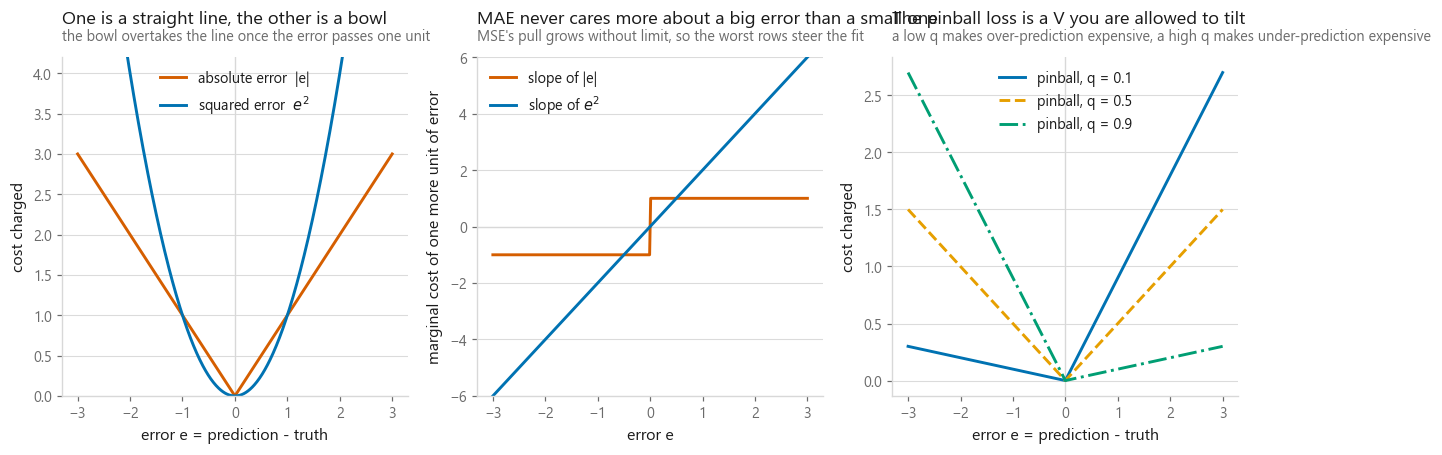

In [3]:
e = np.linspace(-3, 3, 601)

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.0))

axes[0].plot(e, np.abs(e), color=style.HIGHLIGHT, label="absolute error  |e|")
axes[0].plot(e, e ** 2, color=style.PALETTE[0], label="squared error  $e^2$")
axes[0].axvline(0, color=style.RULE, lw=0.9, zorder=0)
axes[0].set_ylim(0, 4.2)
axes[0].set_xlabel("error e = prediction - truth")
axes[0].set_ylabel("cost charged")
axes[0].legend()
style.title(axes[0], "One is a straight line, the other is a bowl",
            "the bowl overtakes the line once the error passes one unit")

# The slope is what a fitting routine actually feels, so it deserves its own panel.
axes[1].plot(e, np.sign(e), color=style.HIGHLIGHT, label="slope of |e|")
axes[1].plot(e, 2 * e, color=style.PALETTE[0], label="slope of $e^2$")
axes[1].axhline(0, color=style.RULE, lw=0.9, zorder=0)
axes[1].set_ylim(-6, 6)
axes[1].set_xlabel("error e")
axes[1].set_ylabel("marginal cost of one more unit of error")
axes[1].legend()
style.title(axes[1], "MAE never cares more about a big error than a small one",
            "MSE's pull grows without limit, so the worst rows steer the fit")

for i, q in enumerate([0.1, 0.5, 0.9]):
    err = -e  # pinball is written in terms of (truth - prediction)
    axes[2].plot(e, np.maximum(q * err, (q - 1) * err), color=style.PALETTE[i],
                 ls=style.DASHES[i], label=f"pinball, q = {q}")
axes[2].axvline(0, color=style.RULE, lw=0.9, zorder=0)
axes[2].set_xlabel("error e = prediction - truth")
axes[2].set_ylabel("cost charged")
axes[2].legend()
style.title(axes[2], "The pinball loss is a V you are allowed to tilt",
            "a low q makes over-prediction expensive, a high q makes under-prediction expensive")

style.save(fig, FIG / "fig-01-loss-shapes.png")

The middle panel is the one that explains the rest of the notebook. Under MAE the
marginal cost of another unit of error is the same whether you are already off by
a little or off by an enormous amount. Under MSE it grows linearly, without
bound, which means a fitting routine will happily make a hundred rows slightly
worse in exchange for making one terrible row less terrible.

That is not a bug. It is a preference, and sometimes it is the right one. But it
has consequences that are easy to walk into unaware.

## 3. Mean against median, and what that costs you

Here is the sharpest version of the claim. Strip away the model entirely and ask
for a single constant $c$ to predict every row with. Then:

$$\arg\min_c \frac{1}{n}\sum_i (y_i - c)^2 = \text{mean}(y)
\qquad
\arg\min_c \frac{1}{n}\sum_i |y_i - c| = \text{median}(y)$$

Both fall out of setting the derivative to zero. For the squared version, the
derivative is $-\frac{2}{n}\sum_i (y_i - c)$, which is zero exactly when $c$ is
the average. For the absolute version, the derivative is
$\frac{1}{n}\big(\#\{y_i < c\} - \#\{y_i > c\}\big)$, which is zero exactly when
the same number of points sit on each side — the definition of the median.

I would rather see it than take my word for it, so I sweep $c$ across the bike
counts and read the two minima off the curves.

argmin of MSE over the grid :   189.50   mean of the data   :   189.46
argmin of MAE over the grid :   142.00   median of the data :   142.00

gap between the two answers : 47.5 bikes per hour


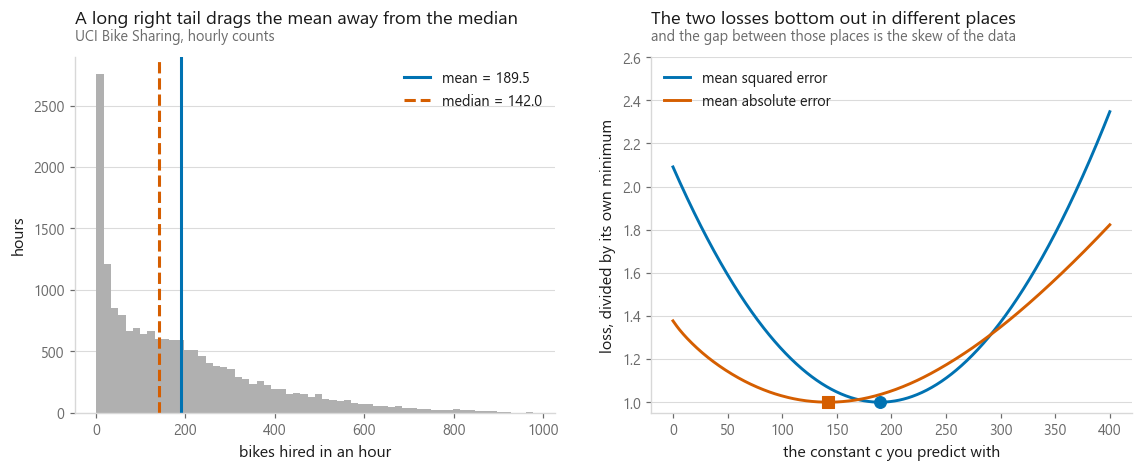

In [4]:
grid = np.linspace(0, 400, 801)
mse_curve = np.array([np.mean((bike - c) ** 2) for c in grid])
mae_curve = np.array([np.mean(np.abs(bike - c)) for c in grid])

c_mse, c_mae = grid[mse_curve.argmin()], grid[mae_curve.argmin()]

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].hist(bike, bins=60, color=style.NEUTRAL)
axes[0].axvline(bike.mean(), color=style.PALETTE[0], lw=2,
                label=f"mean = {bike.mean():.1f}")
axes[0].axvline(np.median(bike), color=style.HIGHLIGHT, lw=2,
                ls="--", label=f"median = {np.median(bike):.1f}")
axes[0].set_xlabel("bikes hired in an hour")
axes[0].set_ylabel("hours")
axes[0].legend()
style.title(axes[0], "A long right tail drags the mean away from the median",
            "UCI Bike Sharing, hourly counts")

# Each curve is divided by its own minimum so two very different scales can share
# an axis and the horizontal positions of the minima stay comparable.
axes[1].plot(grid, mse_curve / mse_curve.min(), color=style.PALETTE[0],
             label="mean squared error")
axes[1].plot(grid, mae_curve / mae_curve.min(), color=style.HIGHLIGHT,
             label="mean absolute error")
axes[1].scatter([c_mse], [1.0], color=style.PALETTE[0], zorder=5,
                marker=style.MARKERS[0], s=60)
axes[1].scatter([c_mae], [1.0], color=style.HIGHLIGHT, zorder=5,
                marker=style.MARKERS[1], s=60)
axes[1].set_ylim(0.95, 2.6)
axes[1].set_xlabel("the constant c you predict with")
axes[1].set_ylabel("loss, divided by its own minimum")
axes[1].legend()
style.title(axes[1], "The two losses bottom out in different places",
            "and the gap between those places is the skew of the data")

style.save(fig, FIG / "fig-02-mean-and-median.png")

print(f"argmin of MSE over the grid : {c_mse:8.2f}   mean of the data   : {bike.mean():8.2f}")
print(f"argmin of MAE over the grid : {c_mae:8.2f}   median of the data : {np.median(bike):8.2f}")
print(f"\ngap between the two answers : {abs(c_mse - c_mae):.1f} bikes per hour")

The grid finds the mean and the median to within its own resolution, which is
what the algebra promised. On a symmetric target the two would land on top of
each other and none of this would matter. On a skewed one they separate, and the
size of that separation is exactly how much disagreement the choice of metric can
cause.

The pinball loss puts the same fact in a wider frame: minimising $L_q$ over a
constant returns the $q$-th quantile. MAE is the special case $q = 0.5$, and the
median is just the fiftieth percentile.

In [5]:
from sklearn.metrics import mean_pinball_loss

wide = np.linspace(0, 600, 1201)
for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    losses = np.array([mean_pinball_loss(bike, np.full_like(bike, c), alpha=q) for c in wide])
    print(f"q = {q:<5} argmin {wide[losses.argmin()]:7.1f}   "
          f"empirical {q:.0%} quantile {np.quantile(bike, q):7.1f}")

q = 0.1   argmin     9.0   empirical 10% quantile     9.0


q = 0.25  argmin    40.0   empirical 25% quantile    40.0


q = 0.5   argmin   142.0   empirical 50% quantile   142.0


q = 0.75  argmin   281.0   empirical 75% quantile   281.0


q = 0.9   argmin   452.0   empirical 90% quantile   451.2


That is worth holding on to, because it tells you what to reach for when the
question is not "what is the typical value" but "give me a number the truth will
fall below nine times out of ten". Inventory levels, delivery estimates and
capacity planning are all quantile questions wearing a regression costume, and
fitting them against MSE answers a question nobody asked.

### The same split, on a model

A constant predictor is a model with no features. Add one feature and nothing
changes except that the argument now runs inside each group rather than across
the whole dataset. I predict bike hires from the hour of the day alone. A model
fitted under squared error should land on each hour's mean; the same model fitted
under absolute error should land on each hour's median.

                               MAE     RMSE  R squared
predict each hour's mean    88.100  128.065      0.501
predict each hour's median  87.007  129.045      0.494

mean absolute distance from the fitted model to each group statistic:
  squared_error   to the means   1.06   to the medians  12.73
  absolute_error  to the means  11.38   to the medians   1.17


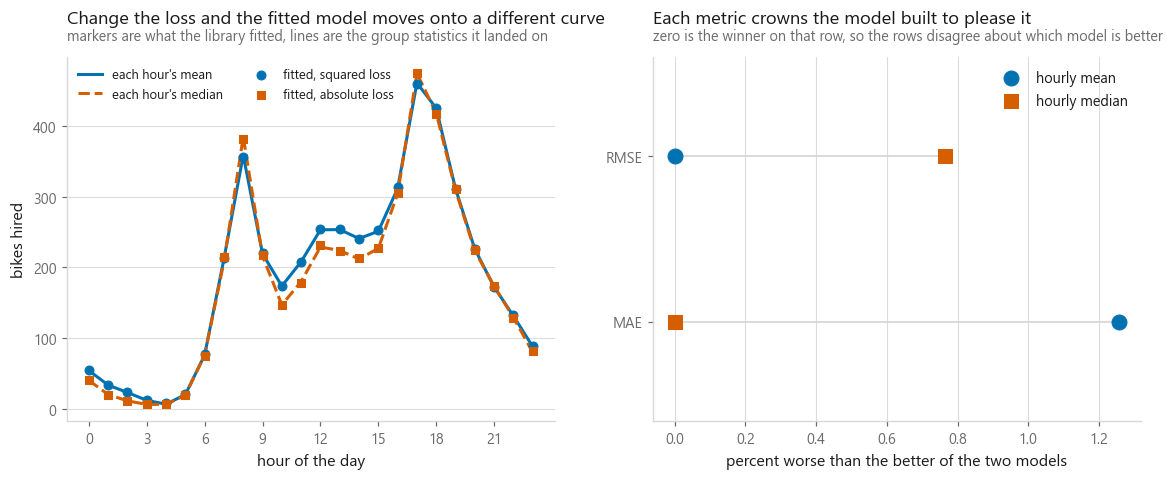

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

hour = X_bike["hr"].to_numpy()
by_hour = pd.DataFrame({"hr": hour, "cnt": bike}).groupby("hr")["cnt"]
hour_mean, hour_median = by_hour.mean(), by_hour.median()

fitted = {}
for loss in ["squared_error", "absolute_error"]:
    model = HistGradientBoostingRegressor(loss=loss, max_iter=200, random_state=SEED,
                                          categorical_features=[0])
    model.fit(hour[:, None], bike)
    fitted[loss] = model.predict(np.arange(24)[:, None])

pred_mean = hour_mean.reindex(hour).to_numpy()
pred_median = hour_median.reindex(hour).to_numpy()

scores = pd.DataFrame({
    "MAE": [mean_absolute_error(bike, p) for p in (pred_mean, pred_median)],
    "RMSE": [root_mean_squared_error(bike, p) for p in (pred_mean, pred_median)],
    "R squared": [r2_score(bike, p) for p in (pred_mean, pred_median)],
}, index=["predict each hour's mean", "predict each hour's median"])

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.3))

axes[0].plot(hour_mean.index, hour_mean.to_numpy(), color=style.PALETTE[0],
             lw=2, label="each hour's mean")
axes[0].plot(hour_median.index, hour_median.to_numpy(), color=style.HIGHLIGHT,
             lw=2, ls="--", label="each hour's median")
axes[0].scatter(np.arange(24), fitted["squared_error"], color=style.PALETTE[0],
                marker=style.MARKERS[0], s=34, zorder=5, label="fitted, squared loss")
axes[0].scatter(np.arange(24), fitted["absolute_error"], color=style.HIGHLIGHT,
                marker=style.MARKERS[1], s=34, zorder=5, label="fitted, absolute loss")
axes[0].set_xlabel("hour of the day")
axes[0].set_ylabel("bikes hired")
axes[0].set_xticks(range(0, 24, 3))
axes[0].legend(fontsize=8.5, ncol=2)
style.title(axes[0], "Change the loss and the fitted model moves onto a different curve",
            "markers are what the library fitted, lines are the group statistics it landed on")

# The two models are within about a percent of each other on both metrics, so a bar
# chart from zero would show nothing. A dot plot against the winner does.
best = scores.min()
relative = (scores / best - 1) * 100
rows = ["MAE", "RMSE"]
for i, metric in enumerate(rows):
    axes[1].plot([0, relative.loc[:, metric].max()], [i, i], color=style.RULE, lw=1.2, zorder=0)
    axes[1].scatter(relative.loc["predict each hour's mean", metric], i,
                    color=style.PALETTE[0], marker=style.MARKERS[0], s=95, zorder=5)
    axes[1].scatter(relative.loc["predict each hour's median", metric], i,
                    color=style.HIGHLIGHT, marker=style.MARKERS[1], s=95, zorder=5)
axes[1].set_yticks(range(len(rows)), rows)
axes[1].set_ylim(-0.6, 1.6)
axes[1].set_xlabel("percent worse than the better of the two models")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
axes[1].scatter([], [], color=style.PALETTE[0], marker=style.MARKERS[0], s=95,
                label="hourly mean")
axes[1].scatter([], [], color=style.HIGHLIGHT, marker=style.MARKERS[1], s=95,
                label="hourly median")
axes[1].legend()
style.title(axes[1], "Each metric crowns the model built to please it",
            "zero is the winner on that row, so the rows disagree about which model is better")

style.save(fig, FIG / "fig-03-each-metric-its-own-model.png")

print(scores.round(3).to_string())
print("\nmean absolute distance from the fitted model to each group statistic:")
for loss, values in fitted.items():
    print(f"  {loss:15} to the means {np.abs(values - hour_mean.to_numpy()).mean():6.2f}"
          f"   to the medians {np.abs(values - hour_median.to_numpy()).mean():6.2f}")

The markers sit on the curves. Asking scikit-learn for `loss="absolute_error"`
genuinely gives you a model of the conditional median, and the default
`loss="squared_error"` genuinely gives you a model of the conditional mean. Two
different questions, two different answers, same features.

And the right panel shows the consequence. The median model wins on MAE, the mean
model wins on RMSE, and neither ordering is wrong. If you fit under one and report
the other you will conclude your model is slightly worse than it needs to be,
without ever seeing why.

I find the practical rule easier to remember in words. **MSE and RMSE want the
average outcome. MAE wants the typical outcome.** On symmetric data those are the
same sentence. On skewed data — money, counts, durations, almost anything with a
floor at zero and no ceiling — they are different sentences, and you should know
which one you are asking.

## 4. Outliers, and R squared going negative

The other half of the squared-error story is what happens when a few rows are
badly wrong. Before injecting anything, it is worth measuring how concentrated
the error already is on a real fit.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X_cal.values, cal, test_size=0.25,
                                          random_state=SEED)
linear = LinearRegression().fit(X_tr, y_tr)
clean = linear.predict(X_te)
error = clean - y_te

ranked = np.argsort(-np.abs(error))
for share in [0.01, 0.05, 0.10]:
    worst = ranked[:int(len(error) * share)]
    print(f"the worst {share:>4.0%} of rows carry "
          f"{(error[worst] ** 2).sum() / (error ** 2).sum():>6.1%} of the squared error "
          f"and {np.abs(error[worst]).sum() / np.abs(error).sum():>6.1%} of the absolute error")

the worst   1% of rows carry  17.2% of the squared error and   5.5% of the absolute error
the worst   5% of rows carry  45.3% of the squared error and  19.9% of the absolute error
the worst  10% of rows carry  60.1% of the squared error and  31.7% of the absolute error


Squared error is already concentrated on a tiny minority of rows before I do
anything to it. Now I break a handful of predictions on purpose. The failure I
simulate is a decimal point in the wrong place, which is the most common way real
pipelines produce a genuinely enormous error: a unit mix-up, a currency that was
not converted, a duplicated join.

 corrupted    MAE   RMSE  R squared
         0 0.5369 0.7351     0.5912
         2 0.5463 0.8836     0.4093
         6 0.5558 0.9608     0.3016
        10 0.5693 1.0852     0.1091
        26 0.6255 1.5380    -0.7895
        50 0.7044 2.0019    -2.0319
        60 0.7352 2.1411    -2.4680

corrupting 60 of 5160 rows (1.16%) multiplies RMSE by 2.91 and MAE by 1.37


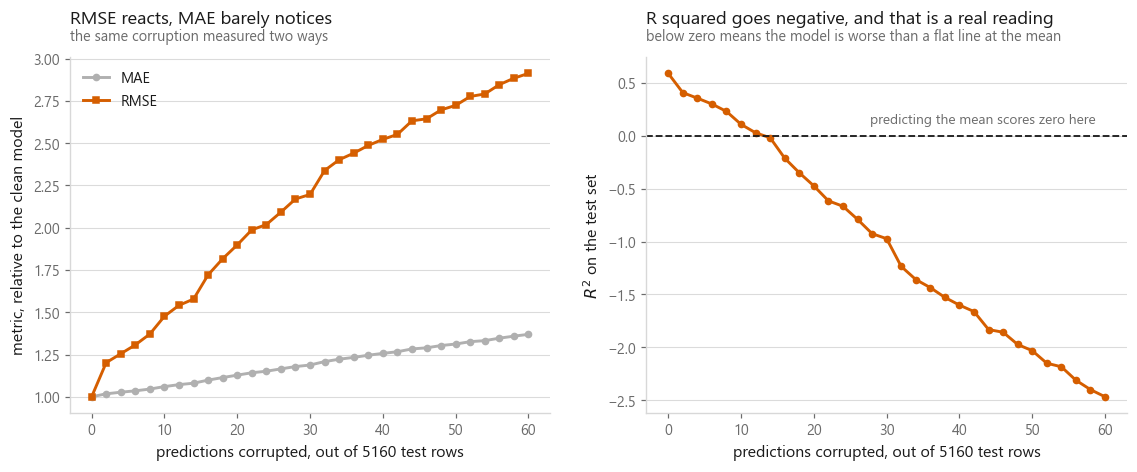

In [8]:
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(SEED)
order = rng.permutation(len(clean))
counts = np.arange(0, 61, 2)

rows = []
for k in counts:
    broken = clean.copy()
    broken[order[:k]] *= 10  # the decimal point slips on k of the test rows
    rows.append({
        "corrupted": k,
        "MAE": mean_absolute_error(y_te, broken),
        "RMSE": root_mean_squared_error(y_te, broken),
        "R squared": r2_score(y_te, broken),
    })
damage = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].plot(damage["corrupted"], damage["MAE"] / damage["MAE"].iloc[0],
             color=style.NEUTRAL, marker=style.MARKERS[0], ms=4, label="MAE")
axes[0].plot(damage["corrupted"], damage["RMSE"] / damage["RMSE"].iloc[0],
             color=style.HIGHLIGHT, marker=style.MARKERS[1], ms=4, label="RMSE")
axes[0].set_xlabel(f"predictions corrupted, out of {len(clean)} test rows")
axes[0].set_ylabel("metric, relative to the clean model")
axes[0].legend()
style.title(axes[0], "RMSE reacts, MAE barely notices",
            "the same corruption measured two ways")

axes[1].plot(damage["corrupted"], damage["R squared"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], ms=4)
axes[1].axhline(0, color=style.INK, lw=1.2, ls="--")
axes[1].annotate("predicting the mean scores zero here", xy=(counts[-1], 0),
                 xytext=(-6, 8), textcoords="offset points", ha="right",
                 fontsize=9, color=style.MUTED)
axes[1].set_xlabel(f"predictions corrupted, out of {len(clean)} test rows")
axes[1].set_ylabel("$R^2$ on the test set")
style.title(axes[1], "R squared goes negative, and that is a real reading",
            "below zero means the model is worse than a flat line at the mean")

style.save(fig, FIG / "fig-04-outliers-take-over-rmse.png")

print(damage.iloc[[0, 1, 3, 5, 13, 25, 30]].round(4).to_string(index=False))
print(f"\ncorrupting {counts[-1]} of {len(clean)} rows ({counts[-1]/len(clean):.2%}) multiplies "
      f"RMSE by {damage['RMSE'].iloc[-1] / damage['RMSE'].iloc[0]:.2f} "
      f"and MAE by {damage['MAE'].iloc[-1] / damage['MAE'].iloc[0]:.2f}")

A fraction of a percent of the rows moves RMSE by a large multiple and MAE by
almost nothing. If you are watching a dashboard and RMSE jumps overnight, the
first thing to check is not the model. It is whether a few rows have gone
strange.

Which of those two behaviours you want depends entirely on the problem. If one
catastrophic error is genuinely catastrophic — a bridge, a dosage, a battery
temperature — you want the metric that screams, and RMSE screams. If your errors
have a fat tail that you cannot do anything about, and you want a number
describing a normal day, RMSE will spend its whole life reporting on the tail and
MAE will tell you about the day.

### What R squared is saying

$R^2$ compares your squared error against the squared error of predicting the
mean every time. Removing all of that error scores one; removing none of it
scores zero. So "this model explains 60% of the variance" means, precisely, that
it removed sixty percent of the squared error that the flat-line model would have
made. It is not a probability, it is not an accuracy, and it says nothing about
whether the remaining error is small enough to be useful.

What it does give you is a number with no units, which is the property RMSE lacks
and the reason both get reported.

In [9]:
bike_hour_pred = pred_mean  # the hourly-mean model from section 3

print("RMSE is in the target's units, so it cannot travel between problems:")
print(f"  California housing, linear model : RMSE {root_mean_squared_error(y_te, clean):7.3f}"
      f"   (hundreds of thousands of dollars)")
print(f"  Bike hires, hour-of-day model    : RMSE {root_mean_squared_error(bike, bike_hour_pred):7.3f}"
      f"   (bikes per hour)")
print("\nR squared has no units, so it can:")
print(f"  California housing, linear model : R2   {r2_score(y_te, clean):7.3f}")
print(f"  Bike hires, hour-of-day model    : R2   {r2_score(bike, bike_hour_pred):7.3f}")

# The blunt way to go negative is an outlier. The quiet way is to predict a
# perfectly sensible constant that simply is not the mean.
print("\nR squared of some constant predictors on the bike counts:")
for label, value in [("the mean", bike.mean()), ("the median", np.median(bike)),
                     ("zero", 0.0)]:
    constant = np.full_like(bike, value)
    print(f"  predict {label:<11} ({value:7.2f}) : R2 {r2_score(bike, constant):9.4f}")

RMSE is in the target's units, so it cannot travel between problems:
  California housing, linear model : RMSE   0.735   (hundreds of thousands of dollars)
  Bike hires, hour-of-day model    : RMSE 128.065   (bikes per hour)

R squared has no units, so it can:
  California housing, linear model : R2     0.591
  Bike hires, hour-of-day model    : R2     0.501

R squared of some constant predictors on the bike counts:
  predict the mean    ( 189.46) : R2    0.0000
  predict the median  ( 142.00) : R2   -0.0685
  predict zero        (   0.00) : R2   -1.0911


The mean scores exactly zero, by construction — it is the model $R^2$ is defined
against. The median scores below zero, on data where the median is arguably the
more sensible summary. That is the sentence to remember: **a negative $R^2$ does
not mean the model is broken, it means the model is worse than the mean at the
one thing $R^2$ measures**, which is squared error. A median-seeking model on
skewed data will sometimes land there while being exactly the model you wanted.

It also means $R^2$ on a test set can be negative even when training went fine,
because the mean it is compared against is the test set's own mean, which the
model never saw. Reported on training data with an ordinary least squares fit,
$R^2$ can never be negative and can only rise when you add features, which is why
training $R^2$ is close to worthless as a model-selection tool.

## 5. MAPE's two failure modes and choosing from cost

MAPE is popular because it produces a percentage, and a percentage sounds like it
means something to everybody in the room. It has two problems, and the second one
is much worse than the first.

### Failure one: the denominator

The formula divides by the truth. If any true value is zero the term is
undefined, and scikit-learn does not raise — it substitutes machine epsilon into
the denominator and hands back an astronomically large number that will silently
poison any average, any grid search, any early-stopping rule it feeds.

In [10]:
from sklearn.metrics import mean_absolute_percentage_error

demo_true = np.array([0.0, 10.0, 20.0, 30.0])
demo_pred = np.array([1.0, 11.0, 19.0, 33.0])
print(f"sklearn MAPE with one true zero in four rows : "
      f"{mean_absolute_percentage_error(demo_true, demo_pred):.3e}")


def mape(y_true, y_pred, floor=1e-9):
    """MAPE over the rows where it is defined, plus a count of the rows it skipped.

    Silently dropping rows changes the question, so the count comes back with the
    number and every caller here prints it.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    usable = np.abs(y_true) > floor
    if not usable.any():
        return np.nan, len(y_true)
    value = np.mean(np.abs(y_true[usable] - y_pred[usable]) / np.abs(y_true[usable]))
    return value, int((~usable).sum())

value, skipped = mape(demo_true, demo_pred)
print(f"guarded MAPE on the same rows               : {value:.3f}   (skipped {skipped} row)")

# The bike counts never hit zero, but they get close enough for the effect to bite.
ape = np.abs(bike - bike_hour_pred) / bike
low = bike <= np.quantile(bike, 0.05)
print(f"\nbike hours in the bottom 5% of counts: {low.mean():.2%} of rows, "
      f"carrying {ape[low].sum() / ape.sum():.1%} of the total percentage error")
print(f"worst single-row percentage error: {ape.max():.0%} "
      f"(true count {bike[ape.argmax()]:.0f})")

sklearn MAPE with one true zero in four rows : 1.126e+15
guarded MAPE on the same rows               : 0.083   (skipped 1 row)

bike hours in the bottom 5% of counts: 6.22% of rows, carrying 31.9% of the total percentage error
worst single-row percentage error: 21106% (true count 1)


No true value in this dataset is zero, so nothing was skipped, and MAPE still
hands a third of its verdict to the quietest hours of the night. Those hours are
usually the ones nobody is trying to forecast. That is failure one in its milder
and more common form: **MAPE weights every row by one over its true value**, so
whichever rows are smallest decide what your model becomes.

### Failure two: it is asymmetric, and it pushes predictions down

For a fixed truth, over-predicting by some amount and under-predicting by the
same amount cost the same. So people say MAPE is symmetric, and in that narrow
sense it is. But look at the range instead of the local slope. Predicting zero is
the worst under-prediction available and it costs one hundred percent. There is
no ceiling on the other side at all.

constant that minimises MSE  :   189.50
constant that minimises MAE  :   142.00
constant that minimises MAPE :     4.00   (the 1/y-weighted median: 4.00)

the three per-hour models, scored every way:
                          MAE      RMSE  R squared    MAPE  mean bias
hourly mean           88.0995  128.0650     0.5015  1.3600     0.0000
hourly median         87.0070  129.0445     0.4938  1.1639    -8.5223
hourly MAPE-optimal  118.1663  184.0993    -0.0302  0.6543  -106.4775


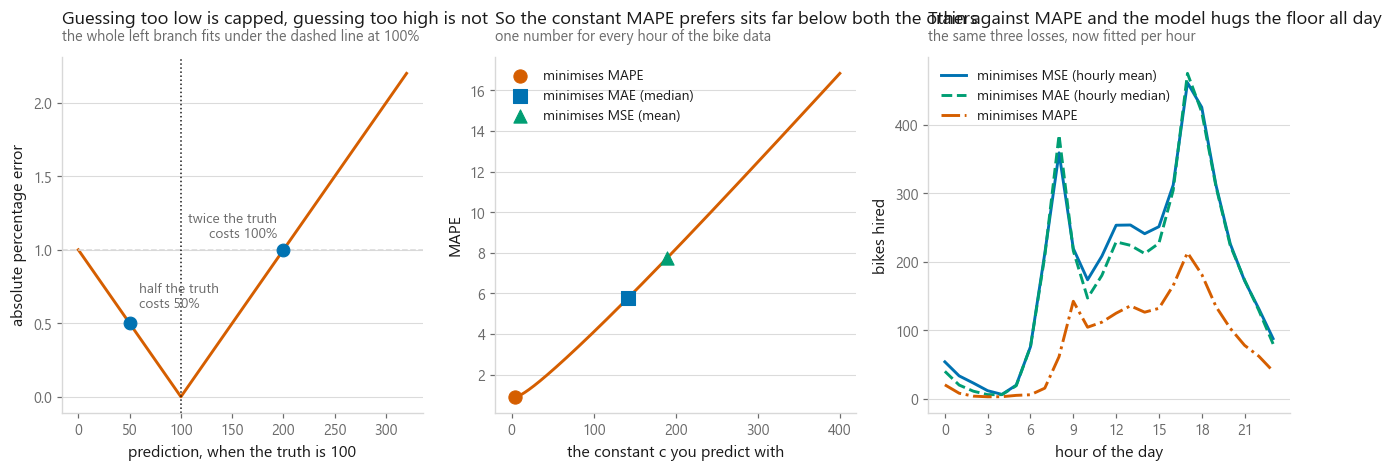

In [11]:
truth = 100.0
pred_axis = np.linspace(0, 320, 641)
ape_curve = np.abs(truth - pred_axis) / truth

mape_curve = np.array([mape(bike, np.full_like(bike, c))[0] for c in grid])
c_mape = grid[mape_curve.argmin()]

# The exact minimiser of MAPE is the median of y weighted by 1/y, which is why it
# sits so far down: the smallest counts get the largest votes.
order_bike = np.sort(bike)
weights = np.cumsum(1.0 / order_bike)
weighted_median = order_bike[np.searchsorted(weights, weights[-1] / 2)]

by_hour_mape = pd.Series(
    {h: np.linspace(0.5, group.max(), 400)[
        np.argmin([np.mean(np.abs(group - c) / group)
                   for c in np.linspace(0.5, group.max(), 400)])]
     for h, group in pd.DataFrame({"hr": hour, "cnt": bike}).groupby("hr")["cnt"]}
)
pred_mape = by_hour_mape.reindex(hour).to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.2))

axes[0].plot(pred_axis, ape_curve, color=style.HIGHLIGHT)
axes[0].axhline(1.0, color=style.RULE, lw=1.0, ls="--")
axes[0].axvline(truth, color=style.INK, lw=1.0, ls=":")
axes[0].scatter([truth / 2, truth * 2], [0.5, 1.0], color=style.PALETTE[0],
                marker=style.MARKERS[0], s=70, zorder=5)
axes[0].annotate("half the truth\ncosts 50%", xy=(truth / 2, 0.5), xytext=(6, 10),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].annotate("twice the truth\ncosts 100%", xy=(truth * 2, 1.0), xytext=(-4, 8),
                 textcoords="offset points", ha="right", fontsize=9, color=style.MUTED)
axes[0].set_xlabel("prediction, when the truth is 100")
axes[0].set_ylabel("absolute percentage error")
style.title(axes[0], "Guessing too low is capped, guessing too high is not",
            "the whole left branch fits under the dashed line at 100%")

axes[1].plot(grid, mape_curve, color=style.HIGHLIGHT)
for value_c, colour, marker, label in [
        (c_mape, style.HIGHLIGHT, style.MARKERS[0], "minimises MAPE"),
        (c_mae, style.PALETTE[0], style.MARKERS[1], "minimises MAE (median)"),
        (c_mse, style.PALETTE[2], style.MARKERS[2], "minimises MSE (mean)")]:
    axes[1].scatter([value_c], [mape_curve[np.abs(grid - value_c).argmin()]],
                    color=colour, marker=marker, s=75, zorder=5, label=label)
axes[1].set_xlabel("the constant c you predict with")
axes[1].set_ylabel("MAPE")
axes[1].legend(fontsize=9)
style.title(axes[1], "So the constant MAPE prefers sits far below both the others",
            "one number for every hour of the bike data")

axes[2].plot(hour_mean.index, hour_mean.to_numpy(), color=style.PALETTE[0],
             label="minimises MSE (hourly mean)")
axes[2].plot(hour_median.index, hour_median.to_numpy(), color=style.PALETTE[2],
             ls="--", label="minimises MAE (hourly median)")
axes[2].plot(by_hour_mape.index, by_hour_mape.to_numpy(), color=style.HIGHLIGHT,
             ls="-.", label="minimises MAPE")
axes[2].set_xlabel("hour of the day")
axes[2].set_ylabel("bikes hired")
axes[2].set_xticks(range(0, 24, 3))
axes[2].legend(fontsize=9)
style.title(axes[2], "Train against MAPE and the model hugs the floor all day",
            "the same three losses, now fitted per hour")

style.save(fig, FIG / "fig-05-mape-is-asymmetric.png")

print(f"constant that minimises MSE  : {c_mse:8.2f}")
print(f"constant that minimises MAE  : {c_mae:8.2f}")
print(f"constant that minimises MAPE : {c_mape:8.2f}   "
      f"(the 1/y-weighted median: {weighted_median:.2f})")

print("\nthe three per-hour models, scored every way:")
table = pd.DataFrame({
    "MAE": [mean_absolute_error(bike, p) for p in (pred_mean, pred_median, pred_mape)],
    "RMSE": [root_mean_squared_error(bike, p) for p in (pred_mean, pred_median, pred_mape)],
    "R squared": [r2_score(bike, p) for p in (pred_mean, pred_median, pred_mape)],
    "MAPE": [mape(bike, p)[0] for p in (pred_mean, pred_median, pred_mape)],
    "mean bias": [np.mean(p - bike) for p in (pred_mean, pred_median, pred_mape)],
}, index=["hourly mean", "hourly median", "hourly MAPE-optimal"])
print(table.round(4).to_string())

The middle panel is the demonstration. The constant that minimises MAPE on the
bike counts sits far below both the mean and the median, close to the bottom of
the range, because minimising MAPE returns the median of the target weighted by
one over the target — and I checked the sweep against that formula in the print
above. Small values carry huge weights, so they win the vote.

The table is the consequence spelled out. The MAPE-optimal model wins on MAPE by
a wide margin, and it is a bad model: it under-predicts every single hour, its
mean bias is large and negative, and its $R^2$ is below zero — worse than a flat
line at the mean, which is section 4's negative $R^2$ arriving from a completely
different direction.

That is what "MAPE biases models downward" means concretely. Nobody chose to
under-forecast. The metric did, and it did it while reporting a number that looks
better than everything else on the table.

### Choosing from the cost of being wrong

I do not think there is a best regression metric, and I think most arguments
about it are people optimising different businesses at each other. The question
that resolves it is always the same: **what does being wrong cost, and how does
that cost grow with the size of the error?** Draw that curve, and the metric is
whichever one from section 2 has the same shape.

If doubling the error roughly doubles the pain, the cost is linear and you want
MAE. If doubling the error more than doubles it — because you blew a threshold,
or a buffer, or somebody's patience — the cost is convex and you want MSE or
RMSE. If the pain depends on the error relative to the size of the thing, so a
ten-unit miss on a large order is nothing and on a small one is a disaster, then
you want a relative metric, and you should reach for a log-target model or a
symmetric relative error rather than MAPE, whose downward bias you now have to
manage. And if being over is a different kind of problem from being under —
stockouts against holding costs, late against early — that is a quantile
question, and the pinball loss lets you name the tilt instead of discovering it
by accident.

The habit worth building is to write the cost sentence down before opening the
metrics module. It takes a minute and it usually changes the answer.

## Cheat sheet

| Metric | Minimising it gives you | Outliers | Units | Watch out for |
|---|---|---|---|---|
| **MAE** | The conditional median | Barely moves it | Target's units | It is deliberately blind to a disaster on a few rows |
| **MSE** | The conditional mean | Dominated by them | Target's units, squared | Unreadable on its own; use it to fit, report RMSE |
| **RMSE** | Same model as MSE | Dominated by them | Target's units | Never comparable across datasets |
| **R squared** | Same model as MSE | Dominated by them | None, so it travels | Goes negative below the mean model; training $R^2$ only ever rises |
| **MAPE** | A 1/y-weighted median, well below the median | Sensitive through the denominator, not the numerator | Percent | Undefined at zero, and it biases models downward |
| **Pinball $L_q$** | The conditional $q$-th quantile | Depends on $q$ | Target's units | $q = 0.5$ is just half of MAE |

Two more that come up. `d2_absolute_error_score` is MAE's answer to $R^2$ —
scale-free, zero for the median model — and it is what to reach for when you want
a unit-free score without squared error's priorities. And when the target spans
orders of magnitude, modelling $\log y$ and reporting RMSE in log space gives you
a relative error measure without any of MAPE's pathologies, at the cost of having
to be careful when you transform predictions back.

## What to remember

1. Minimising squared error gives you the mean, minimising absolute error gives
   you the median. On skewed data those are different models, and each metric
   ranks them in its own favour.
2. RMSE and MSE choose the same model. RMSE just puts the number back into the
   target's units so you can read it.
3. A few large errors take over RMSE and leave MAE alone. Decide which of those
   behaviours matches your problem before you pick.
4. $R^2$ is squared error scored against the mean model. It is unit-free and
   therefore portable, it goes negative when you do worse than a flat line, and
   "explains 60% of the variance" is a statement about squared error and nothing
   else.
5. MAPE is undefined at zero and enormous near it, and it prefers models that
   under-predict. Guard the denominator explicitly, and do not train against it
   without knowing you have signed up for a downward bias.
6. The pinball loss is MAE with a tilt, and it targets a quantile you name. Use
   it whenever being over and being under are different kinds of problem.
7. Pick the metric from the shape of what being wrong costs you. Anything else is
   picking by habit.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-07 Feature scaling and encoding](../07-feature-scaling-and-encoding/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Regression` `#ModelEvaluation` `#Metrics` `#RMSE`
`#RSquared` `#MAPE` `#QuantileRegression` `#Python` `#ScikitLearn` `#DataScience`